2.1.1 Modelos Baseados em L´exicos e Regras

Os modelos baseados em l´exicos e regras utilizam listas de palavras anotadas com po
laridade (positiva ou negativa) e aplicam regras para determinar o sentimento global do
texto. Pode explorar o uso de ferramentas como o TextBlob, o VADER Sentiment Analysis
ou Stanza, entre outras.
Um grupo constitu´ıdo por n elementos deve aplicar e comparar pelo menos n ferra
mentas diferentes. Escolha e aplique as ferramentas aos seus dados de teste e avalie os
resultados obtidos utilizando as m´etricas adotadas. Note que a taxa de acerto (accuracy)
poder´a ser a mais adequada para problemas bin´arios, em que ambas as classes tˆem igual
importˆancia. Para outros problemas poder´a fazer sentido usar outras m´etricas, tais como:
precis˜ao, cobertura e medida F

# Análise de Sentimento - Modelos Baseados em Léxicos

## 1. Setup e Carregamento de Dados

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import nltk

# Download de recursos necessários
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

True

In [9]:
# Carregar dados de teste
df = pd.read_csv("../src/Tweets_EN_sentiment_test.csv")

# Informação básica sobre o dataset
print("Informação do dataset:")
print(df.info())

Informação do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2122 entries, 0 to 2121
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   2122 non-null   int64 
 1   text    2100 non-null   object
 2   class   2122 non-null   object
dtypes: int64(1), object(2)
memory usage: 49.9+ KB
None


o textblob e o stanza tem de ter os dados bem pre-processados, ou seja, sem pontuação, tudo em minúsculas, etc... O vaderSentiment é mais robusto nesse aspeto, mas mesmo assim é melhor fazer algum pré-processamento

fazer lematização, eliminar stopwords, normalização em geral;

no vader é só eliminar elementos não textuais como urls;



In [10]:
stopwords = nltk.corpus.stopwords.words('english')
print("total words:", len(stopwords))
print(stopwords[:90])


total words: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm']



Distribuição de classes:


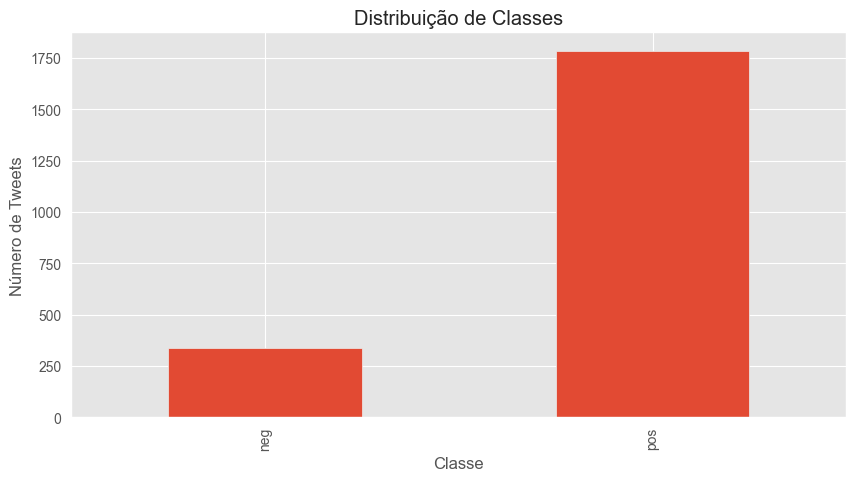

In [11]:
# Distribuição das classes
print("\nDistribuição de classes:")
ax = df['class'].value_counts().sort_index(). \
    plot(kind='bar',
         title='Distribuição de Classes' ,
         figsize=(10, 5))
ax.set_xlabel("Classe")
ax.set_ylabel("Número de Tweets")
plt.show()

In [12]:
# Primeiros exemplos
df.head()

,tweet,text,class
0,1229979438,lmao i love it.,pos
1,1228603001,"Never been to Australia, but I'll keep that in...",pos
2,1228875414,Tired as shit...but what else is new...and don...,neg
3,1231134051,Levi's!,pos
4,1229262160,"no sweetie, its not love, probably just heart ...",pos


In [13]:
from langdetect import detect, DetectorFactory
import pandas as pd

# Garante resultados consistentes em cada execução
DetectorFactory.seed = 0

def analisar_distribuicao_idiomas(df, coluna_texto):

    def detectar_seguro(texto):
        # Validação de integridade: ignora nulos ou strings vazias
        if not texto or pd.isna(texto) or str(texto).strip() == "":
            return "unknown/null"
        try:
            return detect(texto)
        except:
            return "error"

    # Aplicação da lógica e geração de contagem
    print("A processar deteção de idiomas...")
    df['lang_detected'] = df[coluna_texto].apply(detectar_seguro)

    # Retorna a tabela de frequências ordenada
    return df['lang_detected'].value_counts()

# Exemplo de uso:
contagem = analisar_distribuicao_idiomas(tweet, 'text')
print(contagem)

NameError: name 'tweet' is not defined

## 2. Limpeza de Dados

In [14]:
# Remover valores nulos no texto
df_clean = df.dropna(subset=['text']).copy()
print(f"Tweets após remover nulos: {len(df_clean)}")

# Remover textos vazios
df_clean = df_clean[df_clean['text'].str.strip() != '']
print(f"Tweets após remover vazios: {len(df_clean)}")

Tweets após remover nulos: 2100
Tweets após remover vazios: 2100


In [15]:
# Verificar distribuição após limpeza
print("\nDistribuição de classes após limpeza:")
print(df_clean['class'].value_counts())
print(f"\nPercentagem de positivos: {df_clean['class'].value_counts()['pos']/len(df_clean)*100:.1f}%")
print(f"Percentagem de negativos: {df_clean['class'].value_counts()['neg']/len(df_clean)*100:.1f}%")


Distribuição de classes após limpeza:
class
pos    1770
neg     330
Name: count, dtype: int64

Percentagem de positivos: 84.3%
Percentagem de negativos: 15.7%


In [16]:
## 3. Funções de Pré-processamento

In [17]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [18]:
def limpar_para_textblob(text):
    """
    Pré-processamento completo para TextBlob:
    - Lowercase
    - Remover URLs
    - Remover menções (@user)
    - Remover hashtags (#)
    - Remover pontuação
    - Remover stopwords
    - Lematização
    """
    # Lowercase
    text = text.lower()

    # Remover URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remover menções e hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # Remover pontuação e números
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenizar
    tokens = word_tokenize(text)

    # Remover stopwords e lematizar
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]

    return ' '.join(tokens)

In [21]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
from tqdm import tqdm

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ferna\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [27]:
res = {}
for i, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    text = row['text']
    myid = i + 1
    res[myid] = sia.polarity_scores(text)



100%|██████████| 2100/2100 [00:00<00:00, 3728.16it/s]


In [38]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'id'})

df_clean = df_clean.reset_index(drop=True)
vaders = pd.concat([df_clean, vaders], axis=1)

In [40]:
#now we have sentiment scores and metadata
vaders

,tweet,text,class,id,neg,neu,pos,compound
0,1229979438,lmao i love it.,pos,1,0.000,0.110,0.890,0.8442
1,1228603001,"Never been to Australia, but I'll keep that in...",pos,2,0.000,1.000,0.000,0.0000
2,1228875414,Tired as shit...but what else is new...and don...,neg,3,0.205,0.795,0.000,-0.4805
3,1231134051,Levi's!,pos,4,0.000,1.000,0.000,0.0000
4,1229262160,"no sweetie, its not love, probably just heart ...",pos,5,0.330,0.419,0.251,-0.2187
...,...,...,...,...,...,...,...,...
2095,1228266179,Productive day today FTW! Bought/wrapped gifts...,pos,2118,0.000,0.663,0.337,0.8452
2096,1229022249,Thanks,pos,2119,0.000,0.000,1.000,0.4404
2097,1229969913,Nice! Thanks for the info,pos,2120,0.000,0.334,0.666,0.7177
2098,1230580122,"daaaaamn... i shoulda came down there, but you...",neg,2121,0.000,1.000,0.000,0.0000


## Plot Vader Results

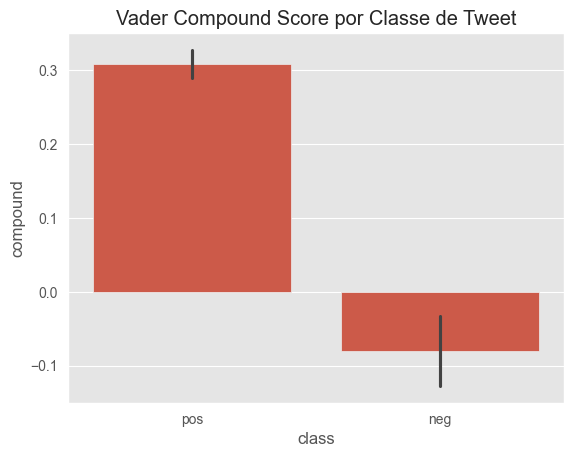

In [41]:
ax = sns.barplot(data=vaders, x='class', y='compound')
ax.set_title("Vader Compound Score por Classe de Tweet")
plt.show()

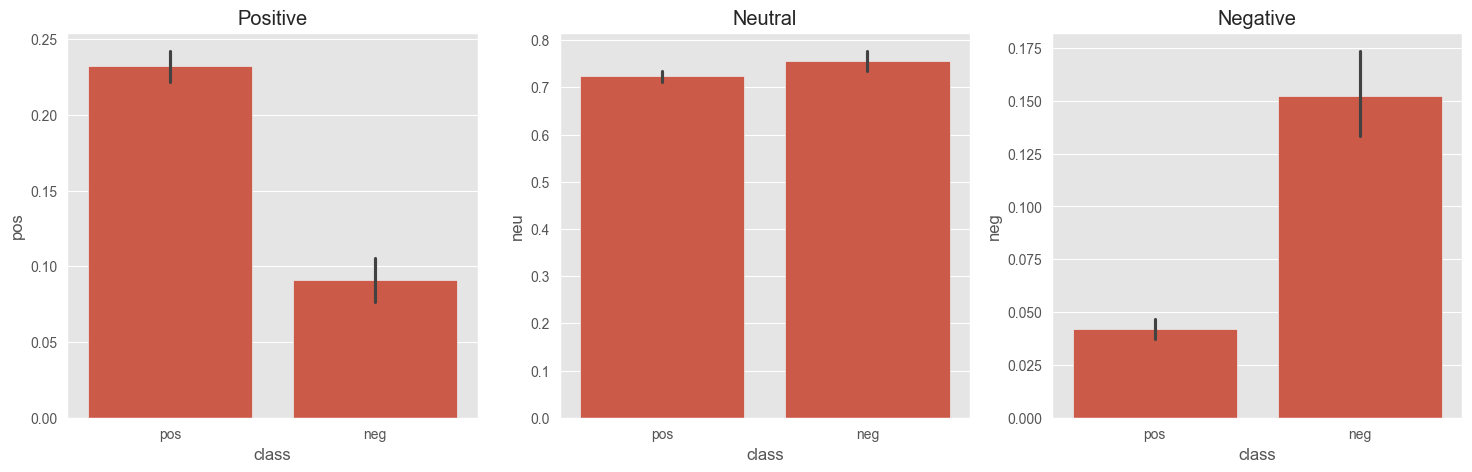

In [44]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=vaders, x='class', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='class', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='class', y='neg', ax=axs[2])
axs[0].set_title("Positive")
axs[1].set_title("Neutral")
axs[2].set_title("Negative")
plt.show()